In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Salary_Dataset_ml_lab.csv")

In [3]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [5]:
df

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
X = df[['YearsExperience']]
Y = df['Salary']

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [25]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [27]:
prediction = model.predict(X_test)

In [29]:
r2 = r2_score(Y_test,prediction)
r2

0.9024461774180498

In [31]:
mse = mean_squared_error(Y_test, prediction)
rmse = np.sqrt(mse)
rmse

7059.043621901506

In [82]:
slope = model.coef_
intercept = model.intercept_

print("-" * 40)
print(f"Slope (m)     : {float(slope):.2f}")
print(f"Intercept (c) : {float(intercept):.2f}")
print("-" * 40)

----------------------------------------
Slope (m)     : 9423.82
Intercept (c) : 24380.20
----------------------------------------


C:\Users\HP\AppData\Local\Temp\ipykernel_18180\2751460839.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Slope (m)     : {float(slope):.2f}")


In [37]:
def model_checking():
    exp = float(input("enter experience; "))
    
    user_data = pd.DataFrame({'YearsExperience' : [exp]})
    pred = float(model.predict(user_data)[0])
    print("-" * 35)
    print(f"Predicted Salary for {exp} years of experience is {pred:,.2f}")
    print("-" * 35)

model_checking()
    

enter experience;  10


-----------------------------------
Predicted Salary for 10.0 years of experience is 118,618.35
-----------------------------------


Text(0.5, 1.0, 'Experience vs Salary')

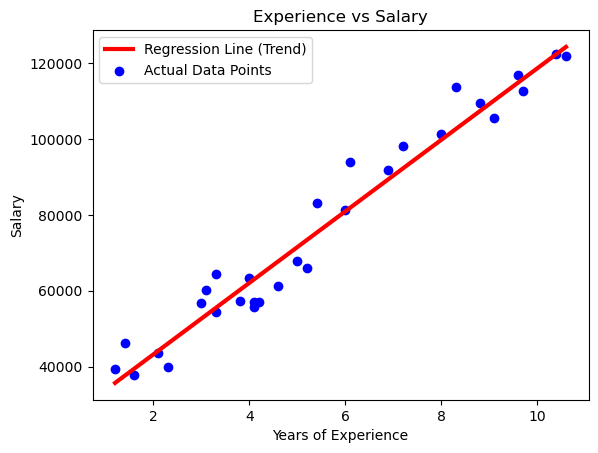

In [70]:
import matplotlib.pyplot as plt
best_fit_predictions = model.predict(df[['YearsExperience']])
plt.plot(df['YearsExperience'], best_fit_predictions, color='red', linewidth=3, label='Regression Line (Trend)')
plt.scatter(df['YearsExperience'], df['Salary'], color='blue',label='Actual Data Points')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.title('Experience vs Salary')

C:\Users\HP\AppData\Local\Temp\ipykernel_18180\1412913031.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


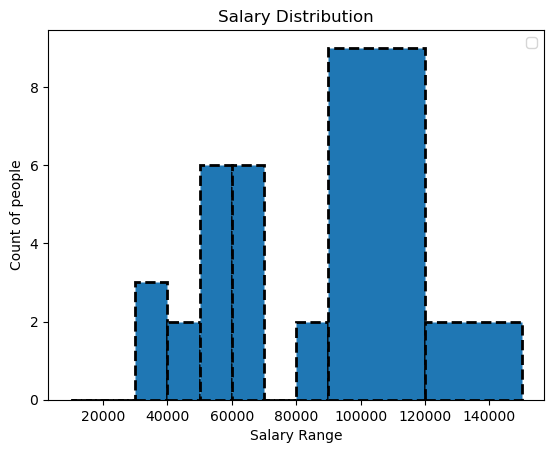

In [71]:
bins = [10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 120000, 150000]

plt.hist(df['Salary'], bins=bins, edgecolor='black', linestyle="--", linewidth = 2 )
plt.xlabel('Salary Range')
plt.ylabel('Count of people')
plt.title('Salary Distribution')
plt.legend()